# TriageFixGraph AI — Exploratory Graph Casebook

Notebook para analizar los datos antes de cambiar el esquema del grafo.

Objetivos:
- Entender qué hay en la muestra exportada de Airtable vs. lo cargado en Neo4j.
- Buscar casos útiles para demo: recurrencia por propiedad, patrones por zona/categoría, proveedor, duplicados, incidencias mixtas.
- Graficar conteos simples para decidir con evidencia.


In [1]:
import sys
print(sys.executable)
print(sys.version)

/Users/erikaprophero/IDE/reviews/triagefixgraph-ai-demo/backend/.venv/bin/python3
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.4.2)]


In [2]:
import os

os.environ["NEO4J_URI"] = "bolt://localhost:7687"
os.environ["NEO4J_USERNAME"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "password"
os.environ["NEO4J_DATABASE"] = "neo4j"

NEO4J_URI = os.environ["NEO4J_URI"]
NEO4J_USERNAME = os.environ["NEO4J_USERNAME"]
NEO4J_PASSWORD = os.environ["NEO4J_PASSWORD"]
NEO4J_DATABASE = os.environ["NEO4J_DATABASE"]

print(NEO4J_URI, NEO4J_USERNAME, NEO4J_DATABASE)

bolt://localhost:7687 neo4j neo4j


In [3]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USERNAME, NEO4J_PASSWORD),
)

with driver.session(database=NEO4J_DATABASE) as session:
    print(session.run("RETURN 1 AS ok").single()["ok"])

driver.close()

1


In [4]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USERNAME, NEO4J_PASSWORD),
)

with driver.session(database=NEO4J_DATABASE) as session:
    print(session.run("RETURN 1 AS ok").single()["ok"])

driver.close()

1


In [5]:
from __future__ import annotations

import ast
import os
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt

try:
    from dotenv import load_dotenv
except Exception:
    load_dotenv = None

from neo4j import GraphDatabase


In [6]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "backend").exists() and (p / "data").exists():
            return p
    return start

REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data"

AIRTABLE_SAMPLE_CSV = DATA_DIR / "airtable_sample" / "incidences_sample.csv"
ENRICHED_CSV = DATA_DIR / "processed" / "enriched_incidents_full.csv"

if load_dotenv:
    load_dotenv(REPO_ROOT / ".env", override=False)
    load_dotenv(REPO_ROOT / "backend" / ".env", override=False)

NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", "neo4j")

print("REPO_ROOT:", REPO_ROOT)
print("Airtable CSV:", AIRTABLE_SAMPLE_CSV, AIRTABLE_SAMPLE_CSV.exists())
print("Enriched CSV:", ENRICHED_CSV, ENRICHED_CSV.exists())
print("Neo4j:", NEO4J_URI, NEO4J_DATABASE)


REPO_ROOT: /Users/erikaprophero/IDE/reviews/triagefixgraph-ai-demo
Airtable CSV: /Users/erikaprophero/IDE/reviews/triagefixgraph-ai-demo/data/airtable_sample/incidences_sample.csv True
Enriched CSV: /Users/erikaprophero/IDE/reviews/triagefixgraph-ai-demo/data/processed/enriched_incidents_demo.csv True
Neo4j: bolt://localhost:7687 neo4j


In [12]:
def normalize_airtable_list(value) -> str:
    if value is None:
        return ""
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return ""
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, list):
                return " | ".join(str(x).strip() for x in parsed if str(x).strip())
        except Exception:
            return text
    return text

def short_text(value, n=140) -> str:
    text = " ".join(str(value or "").split())
    return text if len(text) <= n else text[: n - 3] + "..."

def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        print("Missing:", path)
        return pd.DataFrame()
    return pd.read_csv(path)

def get_driver():
    return GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

def run_cypher(query: str, params: dict | None = None) -> pd.DataFrame:
    with get_driver() as driver:
        with driver.session(database=NEO4J_DATABASE) as session:
            rows = [dict(r) for r in session.run(query, params or {})]
    return pd.DataFrame(rows)

def show_df(df: pd.DataFrame, n=20):
    if df.empty:
        print("(empty)")
    else:
        display(df.head(n))


## 1. Cargar CSV locales y comparar tamaños


In [13]:
airtable_df = load_csv(AIRTABLE_SAMPLE_CSV)

In [14]:
print("ENRICHED_CSV =", ENRICHED_CSV)
p = ENRICHED_CSV
print("exists:", p.exists(), "size:", p.stat().st_size if p.exists() else None)


ENRICHED_CSV = /Users/erikaprophero/IDE/reviews/triagefixgraph-ai-demo/data/processed/enriched_incidents_demo.csv
exists: False size: None


In [15]:
enriched_df = load_csv(ENRICHED_CSV)

Missing: /Users/erikaprophero/IDE/reviews/triagefixgraph-ai-demo/data/processed/enriched_incidents_demo.csv


In [ ]:
'''
graph_count = run_cypher("""
MATCH (i:Incident:TriageFixManaged)
RETURN count(i) AS loaded_incidents
""")

summary = pd.DataFrame([
   # {"source": "Airtable exported sample", "rows": len(airtable_df)},
    {"source": "Enriched CSV loaded sample", "rows": len(enriched_df)},
    #{"source": "Neo4j loaded Incident nodes", "rows": int(graph_count.iloc[0, 0]) if not graph_count.empty else None},
])
display(summary)
'''

## 2. Completeness de la muestra Airtable


In [16]:
type(enriched_df)

pandas.DataFrame

,column,non_empty,total,pct
0,airtable_record_id,1140,1140,100.0
9,Days to resolve,1140,1140,100.0
25,Furniture budget doc__attachment_count,1140,1140,100.0
24,Lease Contract__attachment_count,1140,1140,100.0
23,Incidence docs__attachment_count,1140,1140,100.0
1,airtable_created_time,1140,1140,100.0
10,Days to evaluate,1140,1140,100.0
26,Finance Invoice__attachment_count,1140,1140,100.0
7,Created date,1140,1140,100.0
4,Urgency,1101,1140,96.6


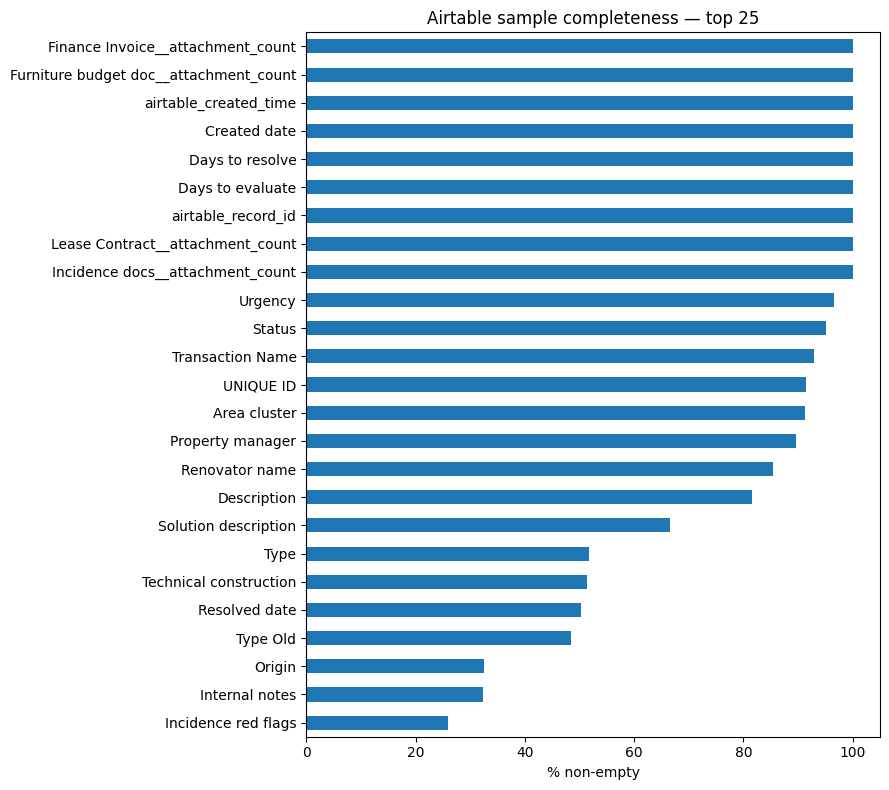

In [17]:
if not airtable_df.empty:
    completeness = airtable_df.notna().sum().rename("non_empty").reset_index().rename(columns={"index": "column"})
    completeness["total"] = len(airtable_df)
    completeness["pct"] = (100 * completeness["non_empty"] / completeness["total"]).round(1)
    display(completeness.sort_values("pct", ascending=False).head(30))

    plot_df = completeness.sort_values("pct").tail(25)
    ax = plot_df.plot.barh(x="column", y="pct", legend=False, figsize=(9, 8))
    ax.set_title("Airtable sample completeness — top 25")
    ax.set_xlabel("% non-empty")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


In [18]:
status_group = (
    airtable_df
    .assign(Status=airtable_df["Status"].fillna("MISSING").astype(str).str.strip())
    .groupby("Status", dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(status_group)

,Status,count
6,Resolved,751
1,Dismissed - Partner,157
7,Resolved - Partner,107
3,MISSING,55
2,Follow up,38
4,Pending - Partner,29
0,Action required,2
5,Pending to evaluate,1


## 3. Conteos de nodos y relaciones en Neo4j


,label,count
0,SeveritySignal,7847
1,HistoricalCase,1121
2,Incident,1121
3,Evidence,1021
4,PropertyContext,627
5,Renovator,105
6,MissingQuestion,24
7,AreaCluster,21
8,Category,10
9,Subcategory,10


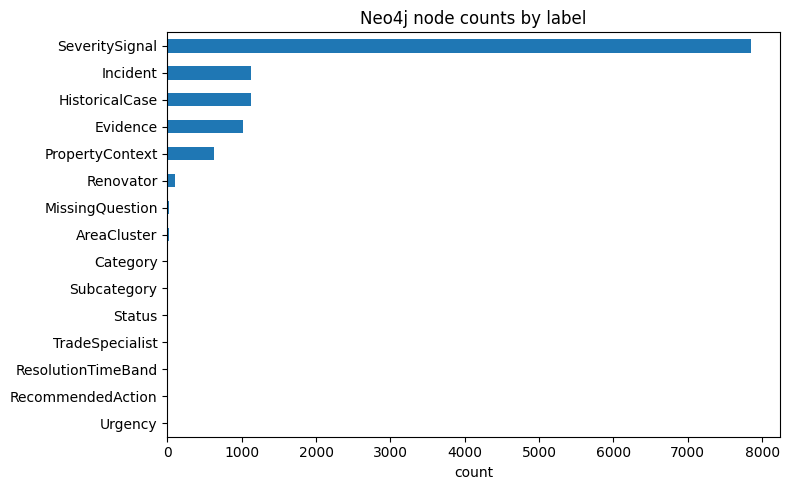

,relationship,count
0,HAS_SEVERITY_SIGNAL,7847
1,PRIOR_SIMILAR,5751
2,NEEDS_QUESTION,5559
3,SIMILAR_TO,1571
4,HAS_CATEGORY,1121
5,HAS_PROPERTY_CONTEXT,1121
6,HAS_RESOLUTION_TIME_BAND,1121
7,HAS_STATUS,1121
8,HAS_SUBCATEGORY,1121
9,HAS_URGENCY,1121


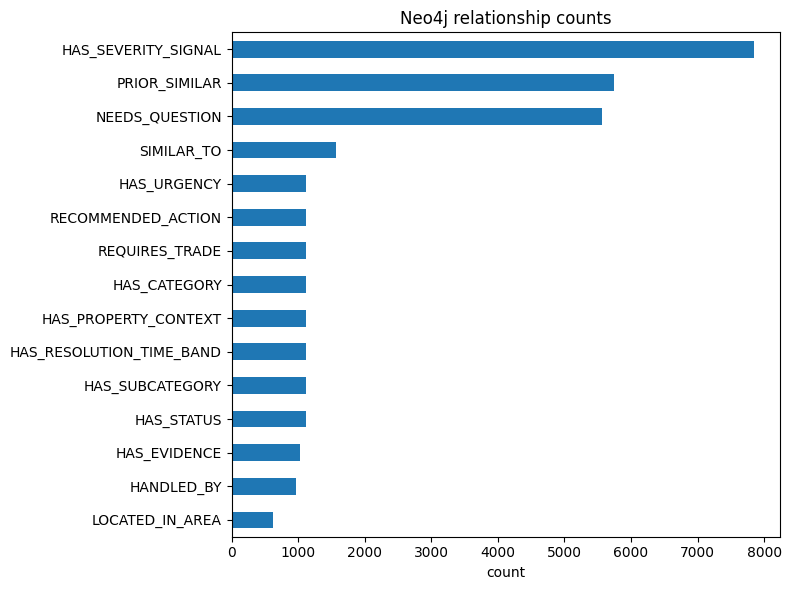

In [10]:
node_counts = run_cypher("""
MATCH (n:TriageFixManaged)
UNWIND [l IN labels(n) WHERE l <> 'TriageFixManaged'] AS label
RETURN label, count(DISTINCT n) AS count
ORDER BY count DESC, label ASC
""")
show_df(node_counts)

if not node_counts.empty:
    ax = node_counts.sort_values("count").plot.barh(x="label", y="count", legend=False, figsize=(8, 5))
    ax.set_title("Neo4j node counts by label")
    ax.set_xlabel("count")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

rel_counts = run_cypher("""
MATCH (:TriageFixManaged)-[r]->(:TriageFixManaged)
RETURN type(r) AS relationship, count(r) AS count
ORDER BY count DESC, relationship ASC
""")
show_df(rel_counts)

if not rel_counts.empty:
    ax = rel_counts.sort_values("count").plot.barh(x="relationship", y="count", legend=False, figsize=(8, 6))
    ax.set_title("Neo4j relationship counts")
    ax.set_xlabel("count")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


## 4. Propiedades con varias incidencias — en Neo4j cargado


In [11]:
same_property_graph = run_cypher("""
MATCH (p:PropertyContext)<-[:HAS_PROPERTY_CONTEXT]-(i:Incident:TriageFixManaged)
OPTIONAL MATCH (i)-[:HAS_CATEGORY]->(c:Category)
WITH p, collect({
  incident_id: i.incident_id,
  date: i.created_date,
  category: c.name,
  severity: i.severity_average,
  description: left(i.clean_description, 160)
}) AS incidents, count(i) AS n
WHERE n > 1
RETURN p.property_context_id AS property, n, incidents
ORDER BY n DESC, property
LIMIT 20
""")
show_df(same_property_graph, 20)


,property,n,incidents
0,SP-2X3-CK2-001010,10,"[{'category': 'Electrodoméstico', 'description..."
1,SP-ISY-25M-000562,10,"[{'category': 'Otro', 'description': 'Inquilin..."
2,SP-7XE-OMC-000501,8,"[{'category': 'Otro', 'description': '-Hay alg..."
3,SP-LMZ-AMC-000659,8,"[{'category': 'Electrodoméstico', 'description..."
4,SP-BHY-MKC-000491,7,"[{'category': 'Puerta / Ventana', 'description..."
5,SP-ETG-GVP-000627,7,"[{'category': 'Otro', 'description': 'Esperand..."
6,SP-FWK-RCU-000400,7,"[{'category': 'Otro', 'description': 'Cajones ..."
7,SP-LVD-ESK-001167,7,"[{'category': 'Fontanería', 'description': 'Fu..."
8,SP-00W-KRK-000927,6,"[{'category': 'Fontanería', 'description': 'El..."
9,SP-EQF-SRG-000470,6,"[{'category': 'Puerta / Ventana', 'description..."


## 5. Propiedades con varias incidencias — en los 200 exportados de Airtable


,property_context_id,incidents
0,SP-2X3-CK2-001010,10
1,SP-ISY-25M-000562,10
2,SP-LMZ-AMC-000659,8
3,SP-7XE-OMC-000501,8
4,SP-LVD-ESK-001167,7
5,SP-BHY-MKC-000491,7
6,SP-ETG-GVP-000627,7
7,SP-FWK-RCU-000400,7
8,SP-O5N-XCD-000454,6
9,SP-EQF-SRG-000470,6


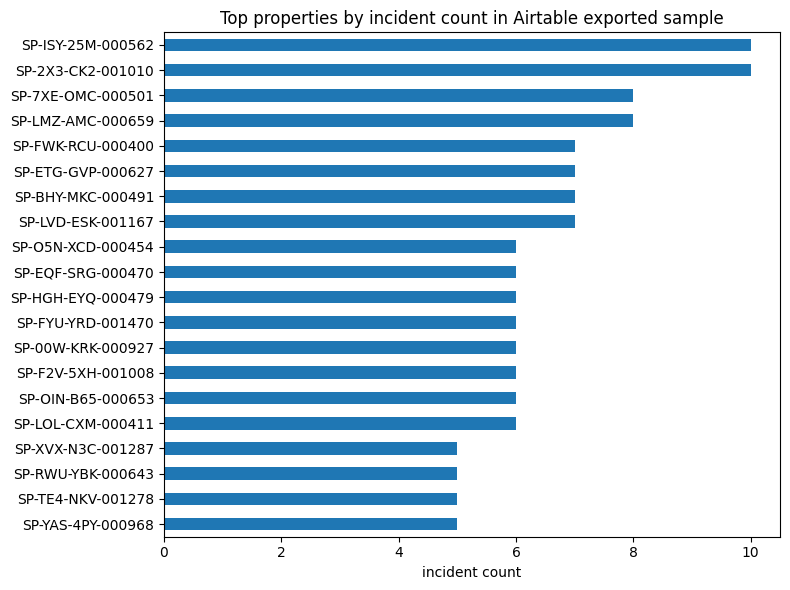

,property,record_id,created_date,urgency,type,renovator,description
0,SP-2X3-CK2-001010,rec4EieSPbjFuayyY,2024-06-04,Low,Electricidad,Juan Manitas,no tienen luz de entrada ni la antena
1,SP-2X3-CK2-001010,recIJo3WDV2JWgrwe,2024-10-09,Low,,Juan Manitas,nan
2,SP-2X3-CK2-001010,recInMciK4gGgfAvw,2024-06-07,Low,Electricidad,Juan Manitas,-hay un foco en la habitación que no se encien...
3,SP-2X3-CK2-001010,receCucCM8oqWBEuk,2025-03-05,Low,Otros,Juan Manitas,Hay una brecha debajo de la pila por donde cre...
4,SP-2X3-CK2-001010,recjkVi3WFd15ADH5,2025-01-23,Low,Otros,Juan Manitas,- les sale agua cuando se duchan en la habitac...
5,SP-ISY-25M-000562,rec7vkq6N0O1z7U0F,2023-11-28,High,,Raimer,24-01-24- Estamos a la espera de confirmación ...
6,SP-ISY-25M-000562,rec8jKLaZyjGzaxqn,2023-11-28,High,,Raimer,nan
7,SP-ISY-25M-000562,recBEOKs4ti72aAza,2024-03-15,Low,,Raimer,+ sumidero de la terraza Adrián Rolando Roncer...
8,SP-ISY-25M-000562,recFJ4pW6I104gJIJ,2023-12-01,High,,Raimer,"La caldera no funciona. A parte, la tapa del v..."
9,SP-ISY-25M-000562,recHkVvlGBhfmHHwO,2024-01-15,Medium,,Raimer,19/01/24 Solucionado En un modo del horno empi...


In [12]:
if not airtable_df.empty:
    raw = airtable_df.copy()
    raw["property_context_id"] = raw["UNIQUE ID"].apply(normalize_airtable_list)
    raw["renovator"] = raw["Renovator name"].apply(normalize_airtable_list) if "Renovator name" in raw else ""
    prop_counts = (
        raw[raw["property_context_id"].astype(bool)]
        .groupby("property_context_id")
        .size()
        .sort_values(ascending=False)
        .rename("incidents")
        .reset_index()
    )

    display(prop_counts.head(30))

    ax = prop_counts.head(20).sort_values("incidents").plot.barh(
        x="property_context_id", y="incidents", legend=False, figsize=(8, 6)
    )
    ax.set_title("Top properties by incident count in Airtable exported sample")
    ax.set_xlabel("incident count")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    # Detailed examples for top properties
    top_props = prop_counts.head(10)["property_context_id"].tolist()
    examples = []
    for prop in top_props:
        for _, r in raw[raw["property_context_id"] == prop].head(5).iterrows():
            examples.append({
                "property": prop,
                "record_id": r.get("airtable_record_id"),
                "created_date": r.get("Created date"),
                "urgency": normalize_airtable_list(r.get("Urgency")),
                "type": normalize_airtable_list(r.get("Type")) or normalize_airtable_list(r.get("Type Old")),
                "renovator": normalize_airtable_list(r.get("Renovator name")),
                "description": short_text(r.get("Description"), 180),
            })
    display(pd.DataFrame(examples))


## 6. Misma propiedad + misma categoría


In [13]:
same_property_category = run_cypher("""
MATCH (p:PropertyContext)<-[:HAS_PROPERTY_CONTEXT]-(i:Incident:TriageFixManaged)-[:HAS_CATEGORY]->(c:Category)
WITH p, c, collect({
  incident_id: i.incident_id,
  date: i.created_date,
  severity: i.severity_average,
  description: left(i.clean_description, 180)
}) AS incidents, count(i) AS n
WHERE n > 1
RETURN p.property_context_id AS property, c.name AS category, n, incidents
ORDER BY n DESC, property, category
LIMIT 20
""")
show_df(same_property_category, 20)


,property,category,n,incidents
0,SP-ISY-25M-000562,Otro,6,[{'description': 'Inquilino: [redacted_phone] ...
1,SP-FWK-RCU-000400,Otro,5,[{'description': 'Cajones cocina rotos Ramón:...
2,SP-O5N-XCD-000454,Otro,4,"[{'description': '', 'severity': 1.71, 'date':..."
3,SP-YAS-4PY-000968,Humedad / Filtración,4,"[{'description': 'Humedades desde el pasillo ,..."
4,SP-YF0-A7M-000955,Fontanería,4,[{'description': 'no le sale agua caliente en ...
5,SP-2X3-CK2-001010,Fontanería,3,[{'description': 'El baño se está inundando y ...
6,SP-2X3-CK2-001010,Otro,3,"[{'description': '', 'severity': 1.29, 'date':..."
7,SP-48E-HXT-000682,Electrodoméstico,3,[{'description': 'Tiene una luz del comedor qu...
8,SP-7XE-OMC-000501,Otro,3,[{'description': '-Hay alguna bombilla del pas...
9,SP-AMC-DZJ-001822,Puerta / Ventana,3,[{'description': 'La puerta del cuadro de luce...


## 7. Misma zona + misma categoría


,area,category,n,incidents
0,unknown,Otro,81,"[{'description': '', 'severity': 1.29, 'date':..."
1,Zona Castellón,Otro,63,"[{'description': '', 'severity': 2.14, 'date':..."
2,Zona Castellón,Fontanería,42,[{'description': 'siniestro en la vivienda 3º9...
3,Zona Sagunto,Otro,37,"[{'description': '', 'severity': 1.29, 'date':..."
4,Zona Sagunto,Fontanería,36,[{'description': 'pérdida de agua del desagüe ...
5,Zaragoza,Otro,30,"[{'description': 'WC no traga bien, de momento..."
6,Horta Sud,Otro,29,"[{'description': 'Bloque 2', 'severity': 2.57,..."
7,Plana Baixa sur,Otro,29,"[{'description': '', 'severity': 1.29, 'date':..."
8,Zona Castellón,Electrodoméstico,29,[{'description': 'La lavadora está dando probl...
9,Toledo,Humedad / Filtración,27,[{'description': '>> FILTRACIÓN BAÑERA E INODO...


category,Electricidad,Electrodoméstico,Fontanería,Humedad / Filtración,Otro,Puerta / Ventana
area,,,,,,
Horta Nord,0,0,0,0,15,0
Horta Sud,0,18,24,0,29,0
La Safor,0,0,13,0,0,0
Plana Baixa sur,0,17,23,0,29,0
Toledo,16,0,0,27,16,0
Zaragoza,0,0,0,0,30,0
Zona Castellón,0,29,42,14,63,26
Zona Sagunto,0,0,36,0,37,0
unknown,0,0,0,0,81,0


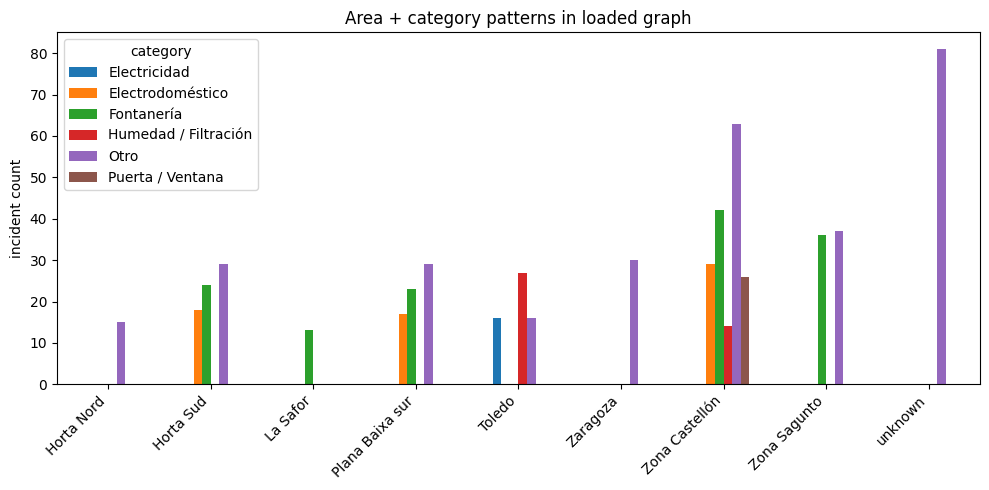

In [14]:
area_category = run_cypher("""
MATCH (i:Incident:TriageFixManaged)-[:HAS_CATEGORY]->(c:Category)
MATCH (i)-[:HAS_PROPERTY_CONTEXT]->(:PropertyContext)-[:LOCATED_IN_AREA]->(a:AreaCluster)
WITH a, c, collect({
  incident_id: i.incident_id,
  date: i.created_date,
  severity: i.severity_average,
  description: left(i.clean_description, 140)
}) AS incidents, count(i) AS n
WHERE n > 1
RETURN a.name AS area, c.name AS category, n, incidents
ORDER BY n DESC, area, category
LIMIT 20
""")
show_df(area_category, 20)

if not area_category.empty:
    pivot = area_category.pivot_table(index="area", columns="category", values="n", aggfunc="sum", fill_value=0)
    display(pivot)
    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Area + category patterns in loaded graph")
    ax.set_ylabel("incident count")
    ax.set_xlabel("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 8. Proveedor / renovator por categoría y zona


In [15]:
provider_category_area = run_cypher("""
MATCH (r:Renovator)<-[:HANDLED_BY]-(i:Incident:TriageFixManaged)
OPTIONAL MATCH (i)-[:HAS_CATEGORY]->(c:Category)
OPTIONAL MATCH (i)-[:HAS_PROPERTY_CONTEXT]->(:PropertyContext)-[:LOCATED_IN_AREA]->(a:AreaCluster)
WITH r, c, a, count(i) AS n, avg(i.severity_average) AS avg_severity,
     collect({
       incident_id: i.incident_id,
       date: i.created_date,
       severity: i.severity_average,
       description: left(i.clean_description, 140)
     }) AS examples
WHERE n > 1
RETURN
  r.name AS provider,
  c.name AS category,
  a.name AS area,
  n,
  round(avg_severity, 2) AS avg_severity,
  examples
ORDER BY n DESC, avg_severity DESC, provider
LIMIT 30
""")
show_df(provider_category_area, 30)


,provider,category,area,n,avg_severity,examples
0,Salva,Humedad / Filtración,Toledo,19,2.28,[{'description': '>> FILTRACIÓN BAÑERA E INODO...
1,MB Group,Otro,Zona Castellón,19,1.97,"[{'description': '', 'severity': 2.14, 'date':..."
2,Jose V. Peris,Otro,Plana Baixa sur,13,1.46,"[{'description': '', 'severity': 1.29, 'date':..."
3,Juan Manitas,Otro,Horta Sud,12,1.61,[{'description': 'Esperando video para determi...
4,Pedro,Otro,Zona Elche,11,1.56,[{'description': '>> ATASCO FREGADERO Fregade...
5,Pedro,Fontanería,Zona Elche,10,1.94,[{'description': 'Comenta la inquilina que el ...
6,Nico,Otro,Zona Castellón,10,1.79,[{'description': 'HAblado con el administrador...
7,MB Group,Fontanería,Zona Castellón,9,2.51,[{'description': 'Calle Monseñor Fernando Ferr...
8,Raimer,Otro,Zaragoza,9,1.98,[{'description': 'Inquilino: [redacted_phone] ...
9,Jose V. Peris,Fontanería,Plana Baixa sur,8,2.27,[{'description': 'no le sale agua caliente en ...


,provider,incidents,categories,avg_severity
0,Pedro,69,"[Humedad / Filtración, Electricidad, Puerta / ...",1.82
1,Jose V. Peris,61,"[Fontanería, Humedad / Filtración, Electricida...",1.86
2,MB Group,49,"[Otro, Puerta / Ventana, Fontanería, Electrodo...",2.20
3,Salva,48,"[Humedad / Filtración, Puerta / Ventana, Elect...",2.03
4,Nico,46,"[Fontanería, Humedad / Filtración, Otro, Puert...",1.98
5,Alnu,41,"[Otro, Puerta / Ventana, Cerradura, Fontanería...",1.94
6,Camer,38,"[Otro, Cerradura, Electricidad, Fontanería, El...",2.03
7,Juan Manitas,33,"[Fontanería, Electrodoméstico, Otro, Humedad /...",1.88
8,César,32,"[Otro, Humedad / Filtración, Fontanería, Cerra...",1.97
9,Sorín,25,"[Otro, Electrodoméstico, Fontanería, Puerta / ...",1.85


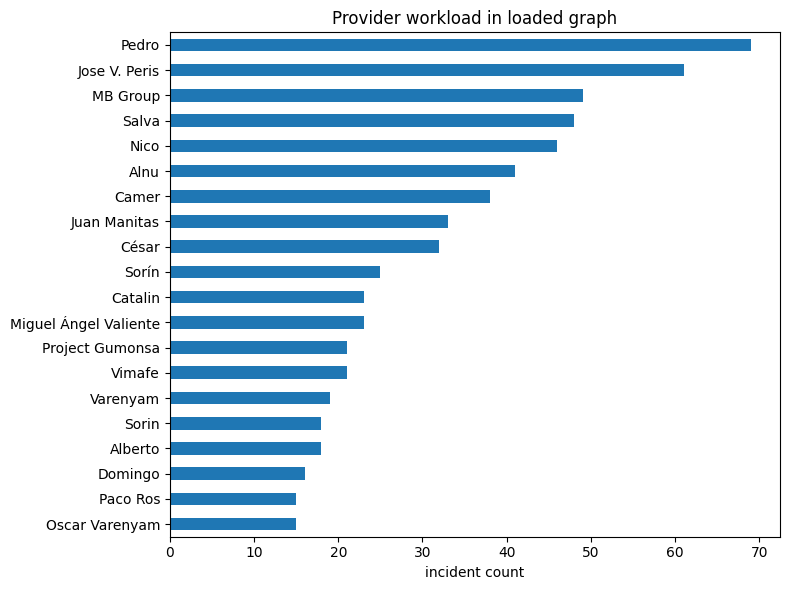

In [16]:
provider_overview = run_cypher("""
MATCH (r:Renovator)<-[:HANDLED_BY]-(i:Incident:TriageFixManaged)
OPTIONAL MATCH (i)-[:HAS_CATEGORY]->(c:Category)
RETURN
  r.name AS provider,
  count(i) AS incidents,
  collect(DISTINCT c.name) AS categories,
  round(avg(i.severity_average), 2) AS avg_severity
ORDER BY incidents DESC, provider
LIMIT 20
""")
show_df(provider_overview, 20)

if not provider_overview.empty:
    ax = provider_overview.sort_values("incidents").plot.barh(
        x="provider", y="incidents", legend=False, figsize=(8, 6)
    )
    ax.set_title("Provider workload in loaded graph")
    ax.set_xlabel("incident count")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


## 9. Relaciones incidente-a-incidente para una incidencia seleccionada


In [17]:
SELECTED_INCIDENT_ID = "recRH51V2eHHlTh9W"

incident_links = run_cypher("""
MATCH (i:Incident:TriageFixManaged {incident_id:$incident_id})
MATCH (i)-[r:PRIOR_SIMILAR|SIMILAR_TO]-(j:Incident:TriageFixManaged)
OPTIONAL MATCH (i)-[:HAS_PROPERTY_CONTEXT]->(pi:PropertyContext)
OPTIONAL MATCH (j)-[:HAS_PROPERTY_CONTEXT]->(pj:PropertyContext)
OPTIONAL MATCH (i)-[:HAS_CATEGORY]->(ci:Category)
OPTIONAL MATCH (j)-[:HAS_CATEGORY]->(cj:Category)
RETURN
  i.incident_id AS selected_incident,
  type(r) AS relationship,
  CASE
    WHEN type(r) = 'PRIOR_SIMILAR' AND startNode(r) = i THEN 'selected_is_prior_for_other'
    WHEN type(r) = 'PRIOR_SIMILAR' AND endNode(r) = i THEN 'other_is_prior_for_selected'
    ELSE 'similar_undirected'
  END AS direction_meaning,
  j.incident_id AS connected_incident,
  r.reason AS reason,
  i.created_date AS selected_date,
  j.created_date AS connected_date,
  ci.name AS selected_category,
  cj.name AS connected_category,
  pi.property_context_id AS selected_property,
  pj.property_context_id AS connected_property,
  left(j.clean_description, 180) AS connected_description
ORDER BY relationship, connected_date
""", {"incident_id": SELECTED_INCIDENT_ID})
show_df(incident_links, 50)


,selected_incident,relationship,direction_meaning,connected_incident,reason,selected_date,connected_date,selected_category,connected_category,selected_property,connected_property,connected_description
0,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,recXcxlcW9CJn6p3I,same_category_area,2024-02-08,2023-11-22,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-EQF-SRG-000470,Falta suministro de agua
1,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,recpoocShE2Yy9F7k,same_category_area,2024-02-08,2023-11-22,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-O5N-XCD-000454,"Calle Monseñor Fernando Ferris 46 planta 2 , p..."
2,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,recsESsV5oROOQ3tw,same_category_area,2024-02-08,2023-12-01,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-CJI-UGR-000530,No sale agua por ese grifo en concreto (ver ví...
3,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,recaBhEZqRX25DWND,same_category_area,2024-02-08,2023-12-01,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-FWK-RCU-000400,Gotea el calentador y no tienen agua caliente ...
4,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,recGcjusEJgLMo8ud,same_category_area,2024-02-08,2023-12-04,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-QIT-DJP-000452,20240102 J&J confirmará si puede enviar a algu...
5,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,recprfJOn3UJ9FhhQ,same_category_area,2024-02-08,2023-12-04,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-DYJ-ZRW-000632,En el grifo del baño solo sale agua caliente y...
6,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,recIz2n2UkukEcpKs,same_category_area,2024-02-08,2023-12-04,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-DYJ-ZRW-000632,"la cisterna del WC no traga bien el agua, no s..."
7,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,recglCzIu8F03nnuf,same_category_area,2024-02-08,2023-12-04,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-VNZ-UFV-000495,Pequeñas reparaciones en circuito de agua
8,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,recYVG5ncGCYABxOi,same_category_area,2024-02-08,2023-12-04,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-VNZ-UFV-000495,Sin agua en la vivienda
9,recRH51V2eHHlTh9W,PRIOR_SIMILAR,other_is_prior_for_selected,rec7UKxwqbSaBYAEf,same_category_area,2024-02-08,2023-12-15,Fontanería,Fontanería,SP-JN3-1W6-000552,SP-IFL-713-000534,-los vidés no funcionan.\n-El wc está saliendo...


## 10. Posibles duplicados


In [18]:
potential_dupes_graph = run_cypher("""
MATCH (p:PropertyContext)<-[:HAS_PROPERTY_CONTEXT]-(i:Incident:TriageFixManaged)
WITH
  p.property_context_id AS property,
  i.created_date AS date,
  left(i.clean_description, 100) AS description_key,
  collect(i.incident_id) AS incident_ids,
  count(i) AS n
WHERE n > 1
RETURN property, date, description_key, n, incident_ids
ORDER BY n DESC, date DESC
LIMIT 20
""")
show_df(potential_dupes_graph, 20)


,property,date,description_key,n,incident_ids
0,SP-HOY-V4P-000135,2023-12-04,,3,"[recuCWtxs0mcSEdDz, recOicIAEDuSnjZRz, recO6ce..."
1,SP-XFL-UVF-002861,2026-05-05,>> NO HAY CONTADOR DE AGUA\n\nContexto:\n\nPao...,2,"[reczkrWkmup36oxVT, recUEJXnv8yCy3Av0]"
2,SP-0MQ-TLS-002485,2025-05-13,,2,"[recXM8wHsXiSBVswf, recJht50vhEkYQgym]"
3,SP-KM3-RXH-000809,2024-02-26,,2,"[recqtLWDRMao0X0xj, recnyUGMX1YMSWGsp]"
4,SP-LOU-OHQ-000786,2024-02-23,,2,"[recmvr10KTQFGgqhh, recOKaK62k7b221s0]"
5,SP-MCV-X2Q-000622,2024-02-23,,2,"[recuCcjn7LJ9O7SeJ, recY0vmV5OShhk041]"
6,SP-SX6-GHO-000306,2024-01-19,inquilino compositora: Guillermo [redacted_phone],2,"[recFL1IyV3YG7dbYT, rec5NWTEnjIJfkYsH]"
7,SP-GEK-QPB-000229,2024-01-15,,2,"[recWOCjchW6nIHE6n, recAsAANQ2jXEpURt]"
8,SP-VMQ-PNT-000611,2023-12-15,,2,"[recvt0fpYu6MEtLvU, rec0G4s7sUpeyD7HM]"
9,SP-TKW-GSQ-000332,2023-12-07,,2,"[recPl61aAWzRd3dbs, rec96dJdMh1KPiv69]"


In [19]:
if not airtable_df.empty:
    raw = airtable_df.copy()
    raw["property_context_id"] = raw["UNIQUE ID"].apply(normalize_airtable_list)
    raw["description_key"] = raw["Description"].fillna("").map(lambda x: short_text(x, 100))
    dupe_candidates = (
        raw[raw["property_context_id"].astype(bool)]
        .groupby(["property_context_id", "Created date", "description_key"], dropna=False)
        .agg(n=("airtable_record_id", "count"), record_ids=("airtable_record_id", lambda x: list(x)))
        .reset_index()
        .query("n > 1")
        .sort_values(["n", "Created date"], ascending=[False, False])
    )
    display(dupe_candidates.head(30))


,property_context_id,Created date,description_key,n,record_ids
440,SP-HOY-V4P-000135,2023-12-04,,3,"[recO6ceVhbyT1eBed, recOicIAEDuSnjZRz, recuCWt..."
923,SP-XFL-UVF-002861,2026-05-05,>> NO HAY CONTADOR DE AGUA Contexto: Paola Pez...,2,"[recUEJXnv8yCy3Av0, reczkrWkmup36oxVT]"
13,SP-0MQ-TLS-002485,2025-05-13,,2,"[recJht50vhEkYQgym, recXM8wHsXiSBVswf]"
530,SP-KM3-RXH-000809,2024-02-26,,2,"[recnyUGMX1YMSWGsp, recqtLWDRMao0X0xj]"
579,SP-LOU-OHQ-000786,2024-02-23,,2,"[recOKaK62k7b221s0, recmvr10KTQFGgqhh]"
609,SP-MCV-X2Q-000622,2024-02-23,,2,"[recY0vmV5OShhk041, recuCcjn7LJ9O7SeJ]"
803,SP-SX6-GHO-000306,2024-01-19,inquilino compositora: Guillermo +34 633 38 95 55,2,"[rec5NWTEnjIJfkYsH, recFL1IyV3YG7dbYT]"
398,SP-GEK-QPB-000229,2024-01-15,,2,"[recAsAANQ2jXEpURt, recWOCjchW6nIHE6n]"
880,SP-VMQ-PNT-000611,2023-12-15,,2,"[rec0G4s7sUpeyD7HM, recvt0fpYu6MEtLvU]"
819,SP-TKW-GSQ-000332,2023-12-07,,2,"[rec96dJdMh1KPiv69, recPl61aAWzRd3dbs]"


## 11. Incidencias mixtas


In [20]:
mixed_keywords = [
    "horno", "persiana", "retrete", "lavadora", "desague", "desagüe",
    "luz", "agua", "nevera", "enchufe", "ducha", "grifo"
]

mixed_graph = run_cypher("""
MATCH (i:Incident:TriageFixManaged)
WHERE
  (
    i.clean_description CONTAINS 'horno'
    OR i.clean_description CONTAINS 'persiana'
    OR i.clean_description CONTAINS 'retrete'
    OR i.clean_description CONTAINS 'lavadora'
    OR i.clean_description CONTAINS 'desague'
    OR i.clean_description CONTAINS 'desagüe'
    OR i.clean_description CONTAINS 'luz'
    OR i.clean_description CONTAINS 'agua'
    OR i.clean_description CONTAINS 'nevera'
    OR i.clean_description CONTAINS 'enchufe'
    OR i.clean_description CONTAINS 'ducha'
    OR i.clean_description CONTAINS 'grifo'
  )
  AND size(i.clean_description) > 120
OPTIONAL MATCH (i)-[:HAS_CATEGORY]->(c:Category)
OPTIONAL MATCH (i)-[:HAS_PROPERTY_CONTEXT]->(p:PropertyContext)
RETURN
  i.incident_id AS incident_id,
  i.created_date AS date,
  p.property_context_id AS property,
  c.name AS category,
  i.severity_average AS severity,
  left(i.clean_description, 450) AS description
ORDER BY size(i.clean_description) DESC
LIMIT 20
""")
show_df(mixed_graph, 20)


,incident_id,date,property,category,severity,description
0,recWnsziyEELNaLjP,2025-12-02,SP-KF9-6OQ-001632,Fontanería,2.43,"Persiana del salón: Desde la entrega, la persi..."
1,rec1HZFf9DKIIZctQ,2025-02-05,SP-TE4-NKV-001278,Electricidad,2.71,La cisterna del baño se ha salido - Owner Prop...
2,recrh1oqLzfjBqsrm,2026-03-03,SP-60U-TQD-002927,Electrodoméstico,1.86,>>LAVADORA\n\nINC. INFORMATIVA: Adjunto vídeos...
3,recOSz1cS5lg3bqTD,2026-05-06,SP-CLZ-L42-004125,Electricidad,1.86,>> VARIAS\n\nhttps://mail.google.com/mail/u/2/...
4,recjANlMpRxHwZ0ry,2026-03-13,unknown_property::recjANlMpRxHwZ0ry,Fontanería,2.29,>> FILTRACIÓN DESDE ASEO A LOCAL INFERIOR\n\nN...
5,receiTdvdvVQTZ8cx,2026-04-15,SP-PFG-QCB-003999,Electrodoméstico,1.71,>> PROBLEMA ELECTRICO\n\nhttps://mail.google.c...
6,rec8BipEgKVrfUVxZ,2026-01-09,SP-MTJ-FJF-002634,Humedad / Filtración,2.43,>> FILTRACIONES A ZONAS COMUNES\n\nDías atrás ...
7,reck786JXxhIoZMaP,2026-03-16,SP-UON-GWP-004770,Fontanería,2.71,>> VARIAS\n\nLa vivienda no dispone de llave d...
8,recM6WkmID3izNJnT,2025-02-24,SP-HJE-LCJ-001225,Fontanería,2.43,"En noviembre de 2024, la comunidad nos indicó ..."
9,rec2Xl7BDH4mrQTzr,2025-11-10,SP-WFU-6LR-004185,Fontanería,2.71,- Las llaves de acceso tanto del portal como d...


In [21]:
if not airtable_df.empty:
    raw = airtable_df.copy()
    raw["property_context_id"] = raw["UNIQUE ID"].apply(normalize_airtable_list)
    raw["description_clean"] = raw["Description"].fillna("").astype(str)
    raw["keyword_count"] = raw["description_clean"].str.lower().map(
        lambda text: sum(1 for kw in mixed_keywords if kw in text)
    )
    raw["description_length"] = raw["description_clean"].str.len()
    mixed_raw = (
        raw[(raw["keyword_count"] >= 2) | (raw["description_length"] > 220)]
        .sort_values(["keyword_count", "description_length"], ascending=False)
        [[
            "airtable_record_id", "Created date", "property_context_id",
            "Urgency", "Type", "Type Old", "Renovator name",
            "keyword_count", "description_length", "Description"
        ]]
        .copy()
    )
    for col in ["Urgency", "Type", "Type Old", "Renovator name"]:
        if col in mixed_raw:
            mixed_raw[col] = mixed_raw[col].apply(normalize_airtable_list)
    mixed_raw["Description"] = mixed_raw["Description"].map(lambda x: short_text(x, 450))
    display(mixed_raw.head(30))


,airtable_record_id,Created date,property_context_id,Urgency,Type,Type Old,Renovator name,keyword_count,description_length,Description
546,recWnsziyEELNaLjP,2025-12-02,SP-KF9-6OQ-001632,Low,,Varias,Franco Inflexión,7,1638,"Persiana del salón: Desde la entrega, la persi..."
741,recfgoHuGkJnecvbj,2023-12-05,SP-LOL-CXM-000411,High,,,MB Group,5,866,VER VIDEO!! Contacto inquilino: ALEXEI: +34 63...
85,rec54fm91zBYz9iqc,2026-02-19,SP-N4S-ENN-003424,Low,Electrodoméstico | Carpinterias: Otros | Humed...,Varias,Salva,5,578,>> VARIAS INCIDENCIAS EN COCINA 1-Baldosa mal ...
179,recAe28NtaqyuRyrT,2025-09-17,SP-U3T-GKX-001960,Low,Otros,Otro,Paco Ros,5,398,La cisterna del baño funciona regular; ·la alc...
117,rec74QgtFAHOmfpCo,2026-04-08,SP-LSQ-XNC-003910,Low,Humedad / Filtración | Puerta / Ventana | Sani...,,Vimafe,4,910,>> VARIAS - posible humedad en techo habitació...
296,recI7sQho0ycrmQ69,2025-10-23,SP-QLL-SSH-002288,Low,,Varias,Alnu,4,633,Cortinas caída Hay un televisor en el baño; El...
379,recNR6jdusY3GnHJp,2024-02-08,SP-EQF-SRG-000470,Low,,,Nico,4,519,"-No funciona el horno, salta la luz solo con e..."
723,receve3qNfGDX7R7q,2023-11-28,SP-13W-URO-000223,High,,,Ivan,4,501,- Defecto instalación en termo con perdidas po...
944,recpoocShE2Yy9F7k,2023-11-22,SP-O5N-XCD-000454,High,,,MB Group,4,469,"Calle Monseñor Fernando Ferris 46 planta 2 , p..."
8,rec0f4D3CZC8gBCs9,2024-07-31,SP-LOL-CXM-000411,High,,,MB Group,4,312,Inquilinos nuevos volvieron a reportar estas i...


## 12. Evidencia + preguntas faltantes + severidad


In [22]:
evidence_decision_support = run_cypher("""
MATCH (i:Incident:TriageFixManaged)-[:HAS_EVIDENCE]->(e:Evidence)
MATCH (i)-[:NEEDS_QUESTION]->(q:MissingQuestion)
MATCH (i)-[:HAS_SEVERITY_SIGNAL]->(s:SeveritySignal)
OPTIONAL MATCH (i)-[:RECOMMENDED_ACTION]->(ra:RecommendedAction)
OPTIONAL MATCH (i)-[:HAS_CATEGORY]->(c:Category)
RETURN
  i.incident_id AS incident_id,
  c.name AS category,
  i.severity_average AS severity,
  e.has_incidence_docs AS has_incidence_docs,
  e.incidence_docs_count AS docs,
  ra.name AS action,
  collect(DISTINCT q.text)[0..5] AS missing_questions,
  collect(DISTINCT {dimension: s.dimension, score: s.score}) AS severity_signals,
  left(i.clean_description, 220) AS description
ORDER BY i.severity_average DESC
LIMIT 15
""")
show_df(evidence_decision_support, 15)


,incident_id,category,severity,has_incidence_docs,docs,action,missing_questions,severity_signals,description
0,recprfJOn3UJ9FhhQ,Fontanería,3.71,True,2,Emergency escalation if high severity,"[¿Afecta a vecinos o zonas comunes?, ¿Puedes e...","[{'dimension': 'people_risk', 'score': 4}, {'d...",En el grifo del baño solo sale agua caliente y...
1,reclSxwOBxW9aBmSE,Fontanería,3.71,True,3,Emergency escalation if high severity,"[¿Puedes enviar una foto o vídeo actualizado?,...","[{'dimension': 'extent', 'score': 2}, {'dimens...","-sale agua del grifo de la cocina, cae abajo e..."
2,rec7i2cq4iVkb0eTy,Fontanería,3.71,True,4,Emergency escalation if high severity,"[¿Hay agua acumulada en el suelo?, ¿La fuga es...","[{'dimension': 'worsening_probability', 'score...",- Pierde agua por el grifo de la ducha\n- La m...
3,recpmSLov5J9BJQtw,Electrodoméstico,3.57,True,1,Emergency escalation if high severity,"[¿Puedes enviar una foto o vídeo actualizado?,...","[{'dimension': 'temporal_urgency', 'score': 4}...","-La lavadora pierde agua, se sale por el cajet..."
4,rechxya9xD9qcnbF8,Humedad / Filtración,3.57,True,3,Ask missing questions before assigning provider,"[¿Ha ocurrido antes en la misma vivienda?, ¿El...","[{'dimension': 'material_damage', 'score': 3},...",Datos de contacto\nInquilina: EVELIN\nTeléfono...
5,recdRkmn6o0VwtKLq,Fontanería,3.29,True,1,Assign plumbing specialist,[¿El problema impide usar baño/cocina/entrada ...,"[{'dimension': 'habitability', 'score': 3}, {'...",· En la cocina no hay agua fría.\n· El retrete...
6,recsESsV5oROOQ3tw,Fontanería,3.14,True,3,Assign plumbing specialist,[¿El problema impide usar baño/cocina/entrada ...,"[{'dimension': 'material_damage', 'score': 4},...",No sale agua por ese grifo en concreto (ver ví...
7,recgpWU7WgVun9XSo,Humedad / Filtración,3.14,True,1,Ask missing questions before assigning provider,"[¿La humedad o gotera sigue activa?, ¿Puedes e...","[{'dimension': 'habitability', 'score': 4}, {'...","Ver foto, hay humedades en la pared"
8,reck9GMH1jWDJA7pj,Humedad / Filtración,3.14,True,1,Ask missing questions before assigning provider,"[¿Puedes enviar una foto o vídeo actualizado?,...","[{'dimension': 'worsening_probability', 'score...",inquilino: [redacted_phone] DANIEL\n la vivien...
9,reccqe0FRmmzhlP04,Humedad / Filtración,3.14,True,3,Ask missing questions before assigning provider,"[¿Puedes enviar una foto o vídeo actualizado?,...","[{'dimension': 'material_damage', 'score': 3},...",La pared presenta humedades y está dificultand...


## 13. Manual notes

Candidaturas típicas para demo:

1. **Property history**  
   Misma propiedad con varias incidencias.

2. **Strong recurrence**  
   Misma propiedad + misma categoría.

3. **Area/category pattern**  
   Misma zona + misma categoría.

4. **Provider rationale**  
   Proveedor conectado a historial por categoría/zona.

5. **Data quality / duplicates**  
   Misma propiedad + fecha + descripción similar.

6. **Mixed incident**  
   Una fila contiene varios problemas operativos.


In [23]:
# analizar
SELECTED_INCIDENT_ID = 'rec7i2cq4iVkb0eTy', 'rec4uHJ58WXbY8sfP'

In [24]:
selected_incident = run_cypher("""
MATCH (i:Incident:TriageFixManaged {incident_id: $incident_id})
OPTIONAL MATCH (i)-[:HAS_PROPERTY_CONTEXT]->(p:PropertyContext)
OPTIONAL MATCH (p)-[:LOCATED_IN_AREA]->(a:AreaCluster)
OPTIONAL MATCH (i)-[:HAS_CATEGORY]->(c:Category)
OPTIONAL MATCH (i)-[:HAS_SUBCATEGORY]->(sc:Subcategory)
OPTIONAL MATCH (i)-[:HAS_STATUS]->(s:Status)
OPTIONAL MATCH (i)-[:HAS_URGENCY]->(u:Urgency)
OPTIONAL MATCH (i)-[:HANDLED_BY]->(r:Renovator)
OPTIONAL MATCH (i)-[:RECOMMENDED_ACTION]->(ra:RecommendedAction)
OPTIONAL MATCH (i)-[:REQUIRES_TRADE]->(t:TradeSpecialist)
RETURN
  i.incident_id AS incident_id,
  i.created_date AS created_date,
  i.resolved_date AS resolved_date,
  p.property_context_id AS property_context_id,
  a.name AS area_cluster,
  c.name AS category,
  sc.name AS subcategory,
  s.name AS status,
  u.name AS urgency,
  r.name AS renovator,
  t.name AS trade_specialist,
  ra.name AS recommended_action,
  i.severity_average AS severity_average,
  i.provider_confidence AS provider_confidence,
  left(i.clean_description, 300) AS description_preview
""", {"incident_id": SELECTED_INCIDENT_ID})

selected_incident

,incident_id,created_date,resolved_date,property_context_id,area_cluster,category,subcategory,status,urgency,renovator,trade_specialist,recommended_action,severity_average,provider_confidence,description_preview
0,rec7i2cq4iVkb0eTy,2024-02-07,2024-02-12,SP-E1X-NMO-000461,Zona Castellón,Fontanería,Agua y saneamiento,Resolved,High,Camer,Plumbing specialist,Emergency escalation if high severity,3.71,high,- Pierde agua por el grifo de la ducha\n- La m...


In [25]:
property_history = run_cypher("""
MATCH (selected:Incident:TriageFixManaged {incident_id: $incident_id})-[:HAS_PROPERTY_CONTEXT]->(p:PropertyContext)
MATCH (p)<-[:HAS_PROPERTY_CONTEXT]-(i:Incident:TriageFixManaged)
OPTIONAL MATCH (i)-[:HAS_CATEGORY]->(c:Category)
OPTIONAL MATCH (i)-[:HAS_SUBCATEGORY]->(sc:Subcategory)
OPTIONAL MATCH (i)-[:HAS_STATUS]->(s:Status)
OPTIONAL MATCH (i)-[:HAS_URGENCY]->(u:Urgency)
OPTIONAL MATCH (i)-[:HANDLED_BY]->(r:Renovator)
RETURN
  p.property_context_id AS property_context_id,
  i.incident_id AS incident_id,
  i.created_date AS created_date,
  i.resolved_date AS resolved_date,
  CASE
    WHEN i.incident_id = $incident_id THEN true
    ELSE false
  END AS is_selected_incident,
  CASE
    WHEN i.created_date < selected.created_date THEN 'prior'
    WHEN i.created_date = selected.created_date THEN 'same_date'
    ELSE 'after'
  END AS temporal_position,
  c.name AS category,
  sc.name AS subcategory,
  s.name AS status,
  u.name AS urgency,
  r.name AS renovator,
  i.severity_average AS severity_average,
  left(i.clean_description, 220) AS description_preview
ORDER BY i.created_date ASC, i.incident_id ASC
""", {"incident_id": SELECTED_INCIDENT_ID})

property_history

,property_context_id,incident_id,created_date,resolved_date,is_selected_incident,temporal_position,category,subcategory,status,urgency,renovator,severity_average,description_preview
0,SP-E1X-NMO-000461,recuAu0VN9SsgyWzy,2023-11-27,2023-12-17,False,prior,Electricidad,Instalación eléctrica,Resolved,Medium,Camer,2.00,Llaves en J& Museros.\n\nSolucionar detalles y...
1,SP-E1X-NMO-000461,recyUtLsBIGXnlT9O,2023-11-28,2023-12-17,False,prior,Cerradura,Acceso y seguridad,Resolved,Low,Camer,1.57,Llaves en J& Museros.\nPintado de techo del baño
2,SP-E1X-NMO-000461,rec7i2cq4iVkb0eTy,2024-02-07,2024-02-12,True,same_date,Fontanería,Agua y saneamiento,Resolved,High,Camer,3.71,- Pierde agua por el grifo de la ducha\n- La m...
3,SP-E1X-NMO-000461,recEBRYBiLkQd7AXh,2024-02-29,2024-04-29,False,after,Otro,General,Resolved,Low,Camer,1.29,
4,SP-E1X-NMO-000461,rec4zymCMttD69WEy,2025-10-10,2025-10-23,False,after,Humedad / Filtración,Humedad y filtraciones,Resolved,Low,Camer,2.14,"En el techo del cuarto de baño, los inquilinos..."


In [26]:
property_history = run_cypher("""
MATCH (selected:Incident:TriageFixManaged {incident_id: $incident_id})-[:HAS_PROPERTY_CONTEXT]->(p:PropertyContext)
MATCH (p)<-[:HAS_PROPERTY_CONTEXT]-(i:Incident:TriageFixManaged)
OPTIONAL MATCH (i)-[:HAS_CATEGORY]->(c:Category)
OPTIONAL MATCH (i)-[:HAS_SUBCATEGORY]->(sc:Subcategory)
OPTIONAL MATCH (i)-[:HAS_STATUS]->(s:Status)
OPTIONAL MATCH (i)-[:HAS_URGENCY]->(u:Urgency)
OPTIONAL MATCH (i)-[:HANDLED_BY]->(r:Renovator)
RETURN
  p.property_context_id AS property_context_id,
  i.incident_id AS incident_id,
  i.created_date AS created_date,
  i.resolved_date AS resolved_date,
  CASE
    WHEN i.incident_id = $incident_id THEN true
    ELSE false
  END AS is_selected_incident,
  CASE
    WHEN i.created_date < selected.created_date THEN 'prior'
    WHEN i.created_date = selected.created_date THEN 'same_date'
    ELSE 'after'
  END AS temporal_position,
  c.name AS category,
  sc.name AS subcategory,
  s.name AS status,
  u.name AS urgency,
  r.name AS renovator,
  i.severity_average AS severity_average,
  left(i.clean_description, 220) AS description_preview
ORDER BY i.created_date ASC, i.incident_id ASC
""", {"incident_id": SELECTED_INCIDENT_ID})

property_history

,property_context_id,incident_id,created_date,resolved_date,is_selected_incident,temporal_position,category,subcategory,status,urgency,renovator,severity_average,description_preview
0,SP-E1X-NMO-000461,recuAu0VN9SsgyWzy,2023-11-27,2023-12-17,False,prior,Electricidad,Instalación eléctrica,Resolved,Medium,Camer,2.00,Llaves en J& Museros.\n\nSolucionar detalles y...
1,SP-E1X-NMO-000461,recyUtLsBIGXnlT9O,2023-11-28,2023-12-17,False,prior,Cerradura,Acceso y seguridad,Resolved,Low,Camer,1.57,Llaves en J& Museros.\nPintado de techo del baño
2,SP-E1X-NMO-000461,rec7i2cq4iVkb0eTy,2024-02-07,2024-02-12,True,same_date,Fontanería,Agua y saneamiento,Resolved,High,Camer,3.71,- Pierde agua por el grifo de la ducha\n- La m...
3,SP-E1X-NMO-000461,recEBRYBiLkQd7AXh,2024-02-29,2024-04-29,False,after,Otro,General,Resolved,Low,Camer,1.29,
4,SP-E1X-NMO-000461,rec4zymCMttD69WEy,2025-10-10,2025-10-23,False,after,Humedad / Filtración,Humedad y filtraciones,Resolved,Low,Camer,2.14,"En el techo del cuarto de baño, los inquilinos..."


In [27]:
semantic_similar_cases = run_cypher("""
MATCH (i:Incident:TriageFixManaged {incident_id: $incident_id})-[r:SIMILAR_TO]-(j:Incident:TriageFixManaged)
OPTIONAL MATCH (j)-[:HAS_PROPERTY_CONTEXT]->(p:PropertyContext)
OPTIONAL MATCH (j)-[:HAS_CATEGORY]->(c:Category)
OPTIONAL MATCH (j)-[:HAS_SUBCATEGORY]->(sc:Subcategory)
OPTIONAL MATCH (j)-[:HAS_STATUS]->(s:Status)
OPTIONAL MATCH (j)-[:HANDLED_BY]->(ren:Renovator)
OPTIONAL MATCH (j)-[:RECOMMENDED_ACTION]->(ra:RecommendedAction)
RETURN
  j.incident_id AS similar_incident,
  j.created_date AS created_date,
  p.property_context_id AS property_context_id,
  c.name AS category,
  sc.name AS subcategory,
  s.name AS status,
  ren.name AS renovator,
  ra.name AS recommended_action,
  j.severity_average AS severity_average,
  r.reason AS similarity_reason,
  r.similarity_method AS similarity_method,
  r.similarity_score AS similarity_score,
  left(j.clean_description, 260) AS description_preview
ORDER BY similarity_score DESC
LIMIT 20
""", {"incident_id": SELECTED_INCIDENT_ID})

semantic_similar_cases

""


In [28]:
CLOSED_STATUSES = ["Resolved", "Resolved - Partner", "Dismissed - Partner"]

In [29]:
unresolved_overview = run_cypher("""
MATCH (i:Incident:TriageFixManaged)
OPTIONAL MATCH (i)-[:HAS_STATUS]->(s:Status)
WITH i, coalesce(s.name, 'unknown') AS status
WHERE NOT status IN $closed_statuses
RETURN
  status,
  count(i) AS incidents,
  min(i.created_date) AS min_date,
  max(i.created_date) AS max_date
ORDER BY incidents DESC
""", {"closed_statuses": CLOSED_STATUSES})

unresolved_overview

,status,incidents,min_date,max_date
0,unknown,52,2023-11-22,2026-05-06
1,Follow up,35,2025-10-21,2026-05-06
2,Pending - Partner,25,2026-01-07,2026-05-06
3,Action required,3,2025-11-18,2026-04-20
4,Pending to evaluate,1,2026-05-07,2026-05-07


In [30]:
unresolved_overview = run_cypher("""
MATCH (i:Incident:TriageFixManaged)
OPTIONAL MATCH (i)-[:HAS_STATUS]->(s:Status)
WITH i, coalesce(s.name, 'unknown') AS status
WHERE NOT status IN $closed_statuses
RETURN
  status,
  count(i) AS incidents,
  min(i.created_date) AS min_date,
  max(i.created_date) AS max_date
ORDER BY incidents DESC
""", {"closed_statuses": CLOSED_STATUSES})

unresolved_overview

,status,incidents,min_date,max_date
0,unknown,52,2023-11-22,2026-05-06
1,Follow up,35,2025-10-21,2026-05-06
2,Pending - Partner,25,2026-01-07,2026-05-06
3,Action required,3,2025-11-18,2026-04-20
4,Pending to evaluate,1,2026-05-07,2026-05-07


In [31]:
unresolved_with_property_history = run_cypher("""
MATCH (u:Incident:TriageFixManaged)-[:HAS_PROPERTY_CONTEXT]->(p:PropertyContext)
OPTIONAL MATCH (u)-[:HAS_STATUS]->(us:Status)
WITH u, p, coalesce(us.name, 'unknown') AS unresolved_status
WHERE NOT unresolved_status IN $closed_statuses

MATCH (p)<-[:HAS_PROPERTY_CONTEXT]-(prior:Incident:TriageFixManaged)
WHERE prior.incident_id <> u.incident_id
  AND prior.created_date IS NOT NULL
  AND u.created_date IS NOT NULL
  AND date(prior.created_date) < date(u.created_date)

OPTIONAL MATCH (u)-[:HAS_CATEGORY]->(uc:Category)
OPTIONAL MATCH (u)-[:HAS_URGENCY]->(urg:Urgency)
OPTIONAL MATCH (prior)-[:HAS_CATEGORY]->(pc:Category)
OPTIONAL MATCH (prior)-[:HAS_STATUS]->(ps:Status)
OPTIONAL MATCH (prior)-[:HANDLED_BY]->(pr:Renovator)

RETURN
  u.incident_id AS unresolved_incident,
  u.created_date AS unresolved_date,
  unresolved_status AS unresolved_status,
  p.property_context_id AS property_context_id,
  uc.name AS unresolved_category,
  urg.name AS urgency,
  u.severity_average AS severity_average,
  count(DISTINCT prior) AS prior_same_property_count,
  max(prior.created_date) AS latest_prior_date,
  collect(DISTINCT pc.name) AS prior_categories,
  collect(DISTINCT ps.name) AS prior_statuses,
  collect(DISTINCT pr.name) AS prior_renovators,
  left(u.clean_description, 260) AS unresolved_description
ORDER BY prior_same_property_count DESC, u.severity_average DESC, unresolved_date DESC
LIMIT 50
""", {"closed_statuses": CLOSED_STATUSES})

unresolved_with_property_history

Received notification from DBMS server: <GqlStatusObject gql_status='01G11', status_description='warn: null value eliminated in set function', position=None, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nMATCH (u:Incident:TriageFixManaged)-[:HAS_PROPERTY_CONTEXT]->(p:PropertyContext)\nOPTIONAL MATCH (u)-[:HAS_STATUS]->(us:Status)\nWITH u, p, coalesce(us.name, 'unknown') AS unresolved_status\nWHERE NOT unresolved_status IN $closed_statuses\n\nMATCH (p)<-[:HAS_PROPERTY_CONTEXT]-(prior:Incident:TriageFixManaged)\nWHERE prior.incident_id <> u.incident_id\n  AND prior.created_date IS NOT NULL\n  AND u.created_date IS NOT NULL\n  AND date(prior.created_date) < date(u.created_date)\n\nOPTIONAL MATCH (u)

,unresolved_incident,unresolved_date,unresolved_status,property_context_id,unresolved_category,urgency,severity_average,prior_same_property_count,latest_prior_date,prior_categories,prior_statuses,prior_renovators,unresolved_description
0,reckvOo10qCveaGSU,2026-05-06,Pending - Partner,SP-QON-TVS-000628,Humedad / Filtración,Low,2.29,3,2026-05-05,"[Otro, Electrodoméstico, Puerta / Ventana]","[Resolved, Dismissed - Partner]",[Jose V. Peris],">> FILTRACIÓN VENTANA\n\nEn esta propiedad, ha..."
1,rec4uHJ58WXbY8sfP,2026-03-25,Follow up,SP-N4S-ENN-003424,Humedad / Filtración,Low,2.29,3,2026-02-19,"[Otro, Electrodoméstico]","[Resolved, Dismissed - Partner]",[Salva],>> HUMEDAD
2,recFAgUUbJ7bPTogx,2026-05-05,Follow up,SP-5DX-SCJ-002671,Fontanería,Low,2.71,2,2026-03-03,"[Electricidad, Humedad / Filtración]","[Resolved, Dismissed - Partner]",[Salva],>> PERSIANA Y SUELO\n\nEl parte de seguro se a...
3,recMeVrho79uhOKdw,2026-05-05,Pending - Partner,SP-HBJ-ZDR-004314,Puerta / Ventana,Low,2.71,2,2026-04-17,"[Otro, Limpieza / General]","[Dismissed - Partner, Resolved]",[LyR/Pedro],>> PUERTA CON HUMEDAD Y CERRADURA\n\n\nEl inqu...
4,recqLuh6Ij4OO7b1G,2026-05-05,Follow up,SP-UTR-JR5-002588,Puerta / Ventana,Low,2.43,2,2026-03-26,"[Puerta / Ventana, Otro]","[Dismissed - Partner, Resolved]",[Salva],>> PERSIANA\n\nTUI[redacted_phone] es la\nrefe...
5,rec8wf9hn4ay3XiWu,2026-05-04,Follow up,SP-JCF-3ZY-001354,Humedad / Filtración,Low,2.29,2,2026-02-27,"[Otro, Electricidad]","[Resolved - Partner, Resolved]",[],>> FUGA AGUA + MALOS OLORES\n\n-Fuerte olor a ...
6,recdbfDBfvP2ysZzl,2026-04-29,Follow up,SP-KQF-SUD-001268,Humedad / Filtración,Low,2.29,2,2025-10-10,[Fontanería],"[Dismissed - Partner, Resolved - Partner]",[Diego di Santi],>> FILTRACIÓN\n\nhttps://mail.google.com/mail/...
7,rec7EAmAdsYvNrXxP,2026-04-22,Follow up,SP-ER6-L0L-003139,Humedad / Filtración,Low,2.29,2,2026-03-10,"[Fontanería, Humedad / Filtración]","[Resolved, Dismissed - Partner]",[Salva],>> HUMEDAD\n\nHay una humedad en la pared que ...
8,recbGdpU62ejKkF8C,2026-02-12,Follow up,SP-TLB-GVJ-001094,Otro,Low,1.86,2,2025-11-07,"[Otro, Mobiliario]","[Resolved - Partner, Resolved]",[Sorin],>> MEDIANERA+FACHADA\n\nProblemas varios:\n\n-...
9,recuw9AS63t9zYpA2,2026-04-22,Pending - Partner,SP-VKH-T7D-000419,Otro,Low,1.71,2,2026-04-01,"[Cerradura, Humedad / Filtración]",[Resolved],[Alberto],>> AGUJEROS EN EL CUARTO DE CONTADORES\n\nMe i...


In [32]:
unresolved_with_semantic_similarity = run_cypher("""
MATCH (u:Incident:TriageFixManaged)-[sim:SIMILAR_TO]-(resolved:Incident:TriageFixManaged)
OPTIONAL MATCH (u)-[:HAS_STATUS]->(us:Status)
OPTIONAL MATCH (resolved)-[:HAS_STATUS]->(rs:Status)
WITH
  u,
  resolved,
  sim,
  coalesce(us.name, 'unknown') AS unresolved_status,
  coalesce(rs.name, 'unknown') AS resolved_status
WHERE NOT unresolved_status IN $closed_statuses
  AND resolved_status IN ['Resolved', 'Resolved - Partner']

OPTIONAL MATCH (u)-[:HAS_PROPERTY_CONTEXT]->(up:PropertyContext)
OPTIONAL MATCH (resolved)-[:HAS_PROPERTY_CONTEXT]->(rp:PropertyContext)
OPTIONAL MATCH (u)-[:HAS_CATEGORY]->(uc:Category)
OPTIONAL MATCH (resolved)-[:HAS_CATEGORY]->(rc:Category)
OPTIONAL MATCH (resolved)-[:HANDLED_BY]->(ren:Renovator)
OPTIONAL MATCH (resolved)-[:RECOMMENDED_ACTION]->(ra:RecommendedAction)

RETURN
  u.incident_id AS unresolved_incident,
  u.created_date AS unresolved_date,
  unresolved_status,
  up.property_context_id AS unresolved_property,
  uc.name AS unresolved_category,
  u.severity_average AS unresolved_severity,
  left(u.clean_description, 220) AS unresolved_description,

  resolved.incident_id AS similar_resolved_incident,
  resolved.created_date AS resolved_date,
  resolved_status,
  rp.property_context_id AS resolved_property,
  rc.name AS resolved_category,
  ren.name AS resolved_renovator,
  ra.name AS resolved_action,
  resolved.severity_average AS resolved_severity,
  round(sim.similarity_score, 3) AS similarity_score,
  left(resolved.clean_description, 220) AS resolved_description

ORDER BY similarity_score DESC, unresolved_severity DESC
LIMIT 100
""", {"closed_statuses": CLOSED_STATUSES})

unresolved_with_semantic_similarity

""
